In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append('../')


import torch
from torch.utils.data import random_split, DataLoader, TensorDataset
from src.unet_attention import SuperResModel
from src.utils import *
from loss_function_attention import compute_loss, build_noise_schedule
from foward_process import *
from Reverse_process import *
import os
import numpy as np
import random
import time
import torch.nn.functional as F


device = "cuda:0" if torch.cuda.is_available() else "cpu"


#Generate the bases to import to jupyter
model_base= "../models/"
traing_data_base="../Data/Train/data_aug/"

# Import the data

## Input

In [2]:
# Define the folder path containing .npy files
folder_path = f"{traing_data_base}Aug_nx2.npy"  # Change this to your actual folder path

# List all .npy files in the folder
npy_files = [f for f in os.listdir(folder_path) if f.endswith(".npy")]

# Load all .npy files and store them in a list
arrays = [np.load(os.path.join(folder_path, f)) for f in npy_files]

# Convert the list of arrays into a single NumPy array
# If the arrays have the same shape, you can stack them
low_resolution,_ = normalize_to_range(np.stack(arrays, axis=0),mode='standardize')  # Use np.concatenate if needed
low_resolution = torch.tensor(low_resolution, dtype=torch.float32)


# Print shape of final array
print(f"Final array shape: {low_resolution.shape}")

 **Before Normalization (NumPy)**
   ➤ Min: -6.892890930175781, Max: 5.679842948913574, Mean: 6.421010766644031e-05, Std: 0.9078978896141052

 **After Normalization (NumPy)**
   ➤ Min: -7.592214107513428, Max: 6.2559661865234375, Mean: -4.887581006585151e-09, Std: 0.9999999403953552

Final array shape: torch.Size([10000, 128, 128])


## Cond

In [3]:
# Define the folder path containing .npy files
folder_path = f"{traing_data_base}Aug_sx.npy"  # Change this to your actual folder path

# List all .npy files in the folder
npy_files = [f for f in os.listdir(folder_path) if f.endswith(".npy")]

# Load all .npy files and store them in a list
arrays = [np.load(os.path.join(folder_path, f)) for f in npy_files]

# Convert the list of arrays into a single NumPy array
# If the arrays have the same shape, you can stack them
high_resolution,_ = normalize_to_range(np.stack(arrays, axis=0),mode='standardize')# Use np.concatenate if needed
high_resolution = torch.tensor(high_resolution)

# Print shape of final array
print(f"Final array shape: {high_resolution.shape}")

 **Before Normalization (NumPy)**
   ➤ Min: -6.450832843780518, Max: 6.135650157928467, Mean: -2.1893440589337843e-06, Std: 1.001373052597046

 **After Normalization (NumPy)**
   ➤ Min: -6.441985130310059, Max: 6.12723970413208, Mean: -1.0460615484930713e-08, Std: 1.0

Final array shape: torch.Size([10000, 256, 256])


## Visualization of the data

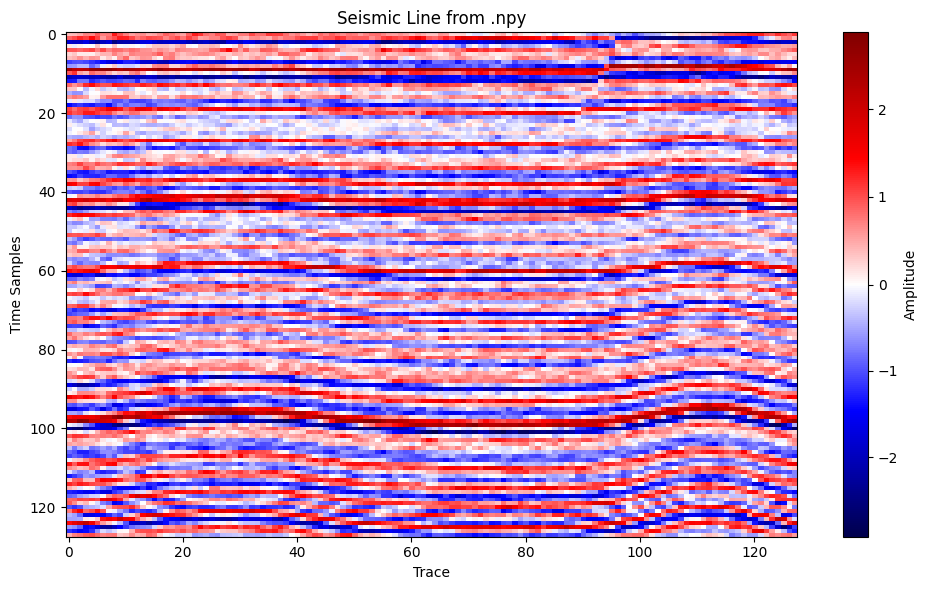

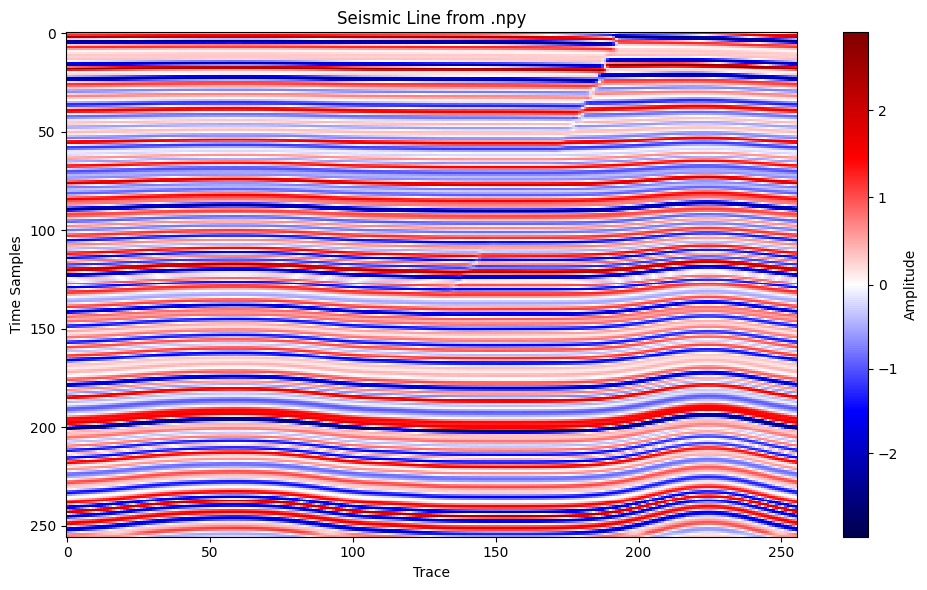

In [4]:
total_samples = 10000
random_index = random.randint(0, total_samples - 1)
plot_2D_seismic(low_resolution[random_index,:,:])
plot_2D_seismic(high_resolution[random_index,:,:])

# Foward Process


In [5]:
num_timesteps=1000
Noise_schedule = build_noise_schedule(num_timesteps, device=device)

In [6]:
# # batch = next(iter(train_dataloader))
# show_noisy_seismic_cubes([[get_noisy_seismic(high_resolution[0], torch.tensor([t])) for t in [0,
#                                                                                               100,
#                                                                                               200,
#                                                                                               300,
#                                                                                               400,
#                                                                                               500,
#                                                                                               600,
#                                                                                               700,
#                                                                                               800,
#                                                                                               900,
#                                                                                               999]]])

# Train process

In [7]:
from torch.optim import Adam


model = SuperResModel(
    data_size=256,
    in_channels=1,
    model_channels=32,
    out_channels=2,
    num_res_blocks=6,
    num_heads=2,
    attention_resolutions=[16],
    dropout=0.0,
    channel_mult=( 4, 8, 16,32),
    dims=2,                    
).to(device)

optimizer = Adam(model.parameters(), lr=1e-4)

In [8]:
def count_params(model):
    """Count the total number of trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



print(f"Model parameters: {count_params(model):,}")

Model parameters: 485,312,258


In [9]:
# Your data
X= high_resolution
Y= low_resolution
dataset = TensorDataset(X, Y)

# Sizes
total_size = len(dataset)
test_size = int(0.10 * total_size)
remaining_size = total_size - test_size
train_size = int(0.90 * remaining_size)
val_size = remaining_size - train_size

# Splits
train_val_dataset, test_dataset = random_split(dataset, [remaining_size, test_size],generator=torch.Generator().manual_seed(42))
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size],generator=torch.Generator().manual_seed(42))

# Loaders
batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Info
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Training dataset size: 8100
Validation dataset size: 900
Test dataset size: 1000


Epoch [1/150] - Train Loss: 0.016062 - Validation Loss: 0.008214 - Time: 4355.42s


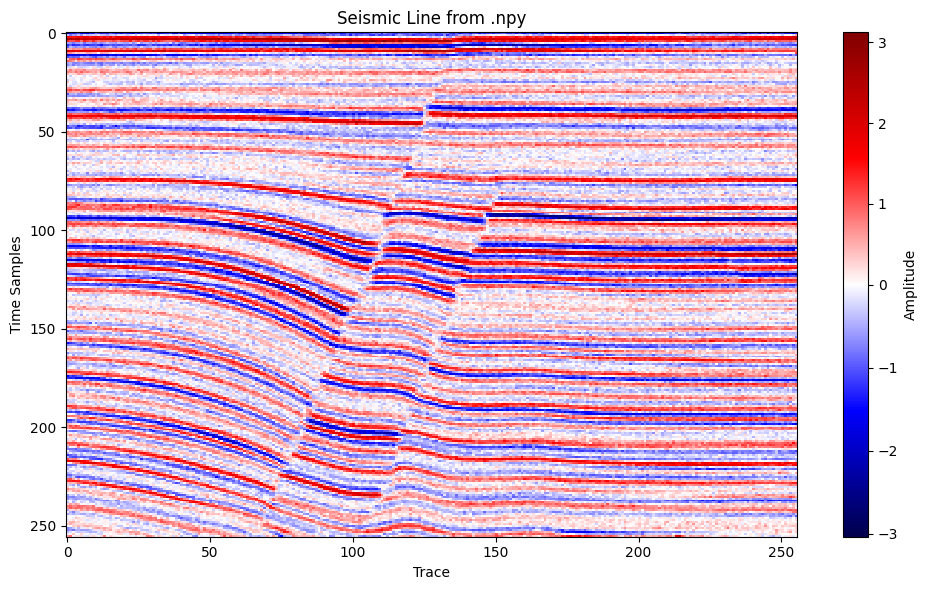

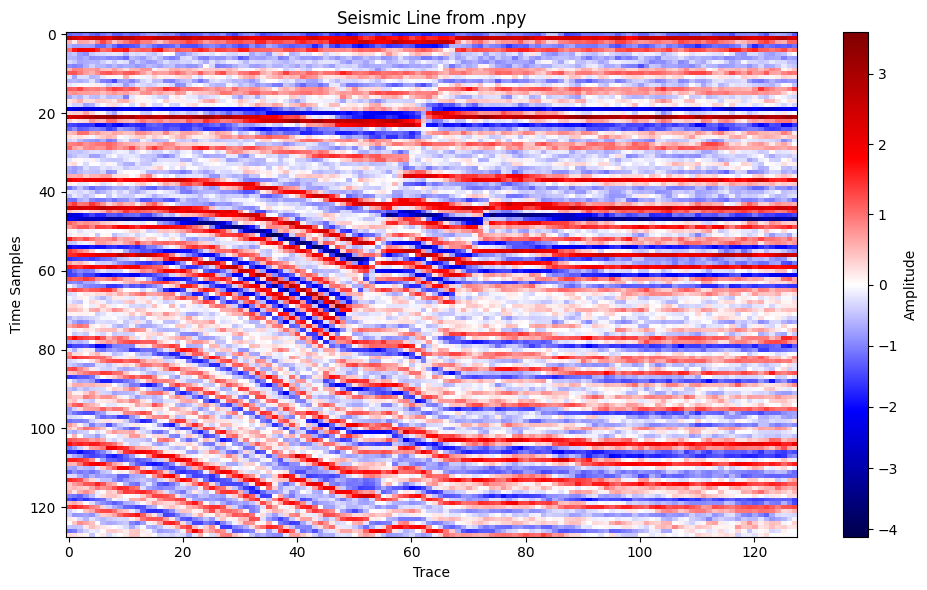

✨ Validation loss improved — model saved!
Epoch [2/150] - Train Loss: 0.007013 - Validation Loss: 0.005896 - Time: 4359.13s
✨ Validation loss improved — model saved!
Epoch [3/150] - Train Loss: 0.005632 - Validation Loss: 0.005147 - Time: 4361.17s
✨ Validation loss improved — model saved!
Epoch [4/150] - Train Loss: 0.004937 - Validation Loss: 0.004783 - Time: 4361.78s
✨ Validation loss improved — model saved!
Epoch [5/150] - Train Loss: 0.004580 - Validation Loss: 0.004318 - Time: 4361.72s
✨ Validation loss improved — model saved!
Epoch [6/150] - Train Loss: 0.004288 - Validation Loss: 0.004147 - Time: 4359.73s
✨ Validation loss improved — model saved!
Epoch [7/150] - Train Loss: 0.004074 - Validation Loss: 0.004089 - Time: 4360.28s
✨ Validation loss improved — model saved!
Epoch [8/150] - Train Loss: 0.003936 - Validation Loss: 0.003926 - Time: 4361.39s
✨ Validation loss improved — model saved!
Epoch [9/150] - Train Loss: 0.003761 - Validation Loss: 0.003981 - Time: 4361.01s
⚠️ No im

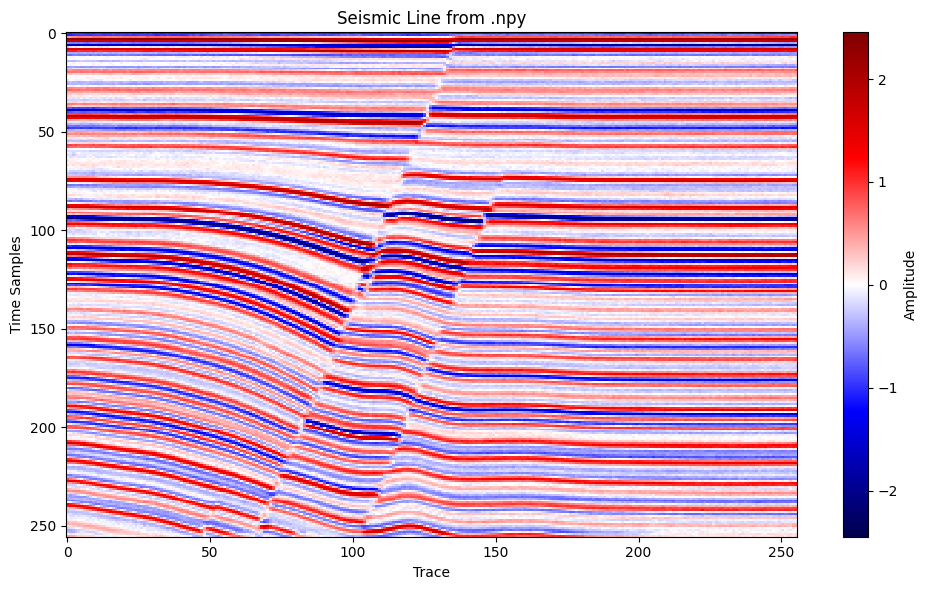

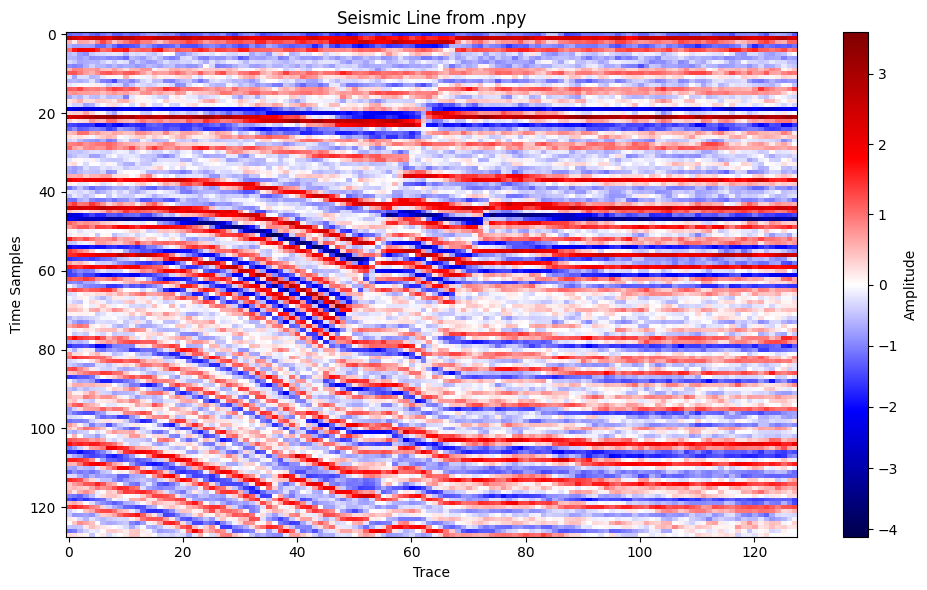

✨ Validation loss improved — model saved!
Epoch [12/150] - Train Loss: 0.003517 - Validation Loss: 0.003611 - Time: 4360.25s
⚠️ No improvement for 1/24 epochs.
Epoch [13/150] - Train Loss: 0.003434 - Validation Loss: 0.003311 - Time: 4360.55s
✨ Validation loss improved — model saved!
Epoch [14/150] - Train Loss: 0.003340 - Validation Loss: 0.003206 - Time: 4347.64s
✨ Validation loss improved — model saved!
Epoch [15/150] - Train Loss: 0.003302 - Validation Loss: 0.003321 - Time: 4347.19s
⚠️ No improvement for 1/24 epochs.
Epoch [16/150] - Train Loss: 0.003300 - Validation Loss: 0.003157 - Time: 4347.38s
✨ Validation loss improved — model saved!
Epoch [17/150] - Train Loss: 0.003232 - Validation Loss: 0.003343 - Time: 4345.14s
⚠️ No improvement for 1/24 epochs.
Epoch [18/150] - Train Loss: 0.003170 - Validation Loss: 0.003145 - Time: 4345.44s
✨ Validation loss improved — model saved!
Epoch [19/150] - Train Loss: 0.003102 - Validation Loss: 0.003102 - Time: 4345.39s
✨ Validation loss imp

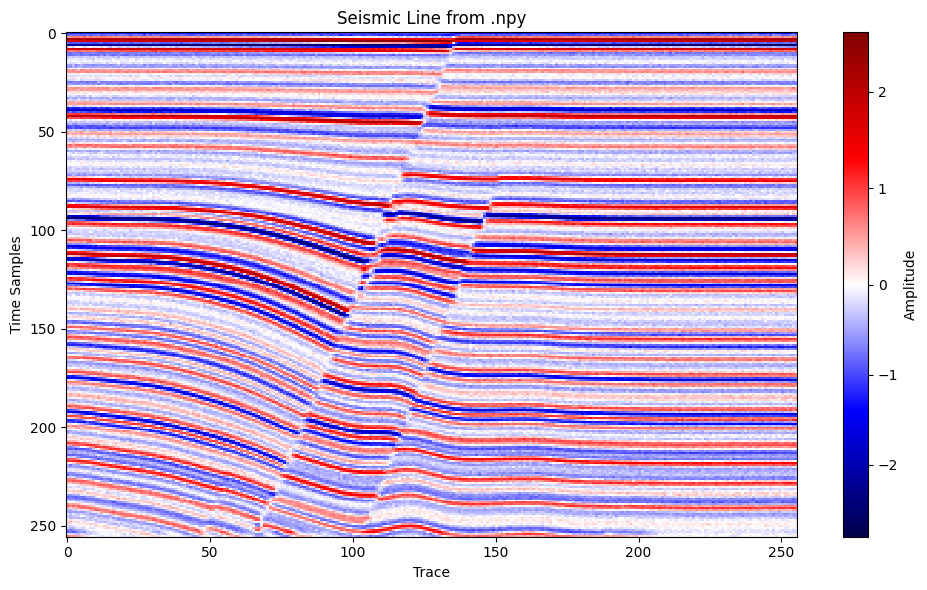

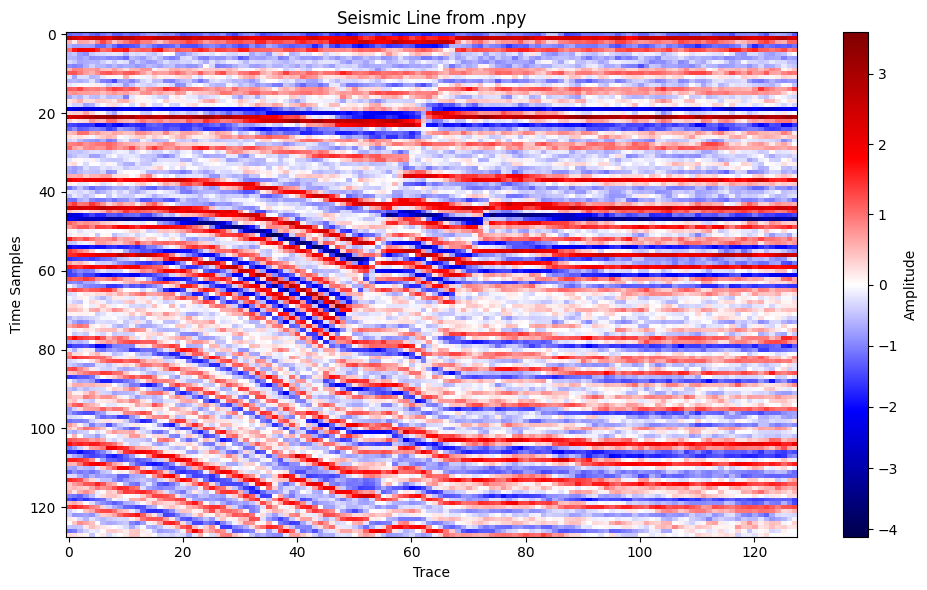

✨ Validation loss improved — model saved!
Epoch [22/150] - Train Loss: 0.003036 - Validation Loss: 0.002902 - Time: 4348.34s
✨ Validation loss improved — model saved!
Epoch [23/150] - Train Loss: 0.002969 - Validation Loss: 0.003044 - Time: 4344.69s
⚠️ No improvement for 1/24 epochs.
Epoch [24/150] - Train Loss: 0.002974 - Validation Loss: 0.002931 - Time: 4344.88s
⚠️ No improvement for 2/24 epochs.
Epoch [25/150] - Train Loss: 0.002950 - Validation Loss: 0.002883 - Time: 4343.51s
✨ Validation loss improved — model saved!
Epoch [26/150] - Train Loss: 0.002934 - Validation Loss: 0.002890 - Time: 4345.91s
⚠️ No improvement for 1/24 epochs.
Epoch [27/150] - Train Loss: 0.002886 - Validation Loss: 0.002941 - Time: 4346.25s
⚠️ No improvement for 2/24 epochs.
Epoch [28/150] - Train Loss: 0.002859 - Validation Loss: 0.002795 - Time: 4345.21s
✨ Validation loss improved — model saved!
Epoch [29/150] - Train Loss: 0.002823 - Validation Loss: 0.002681 - Time: 4344.70s
✨ Validation loss improved —

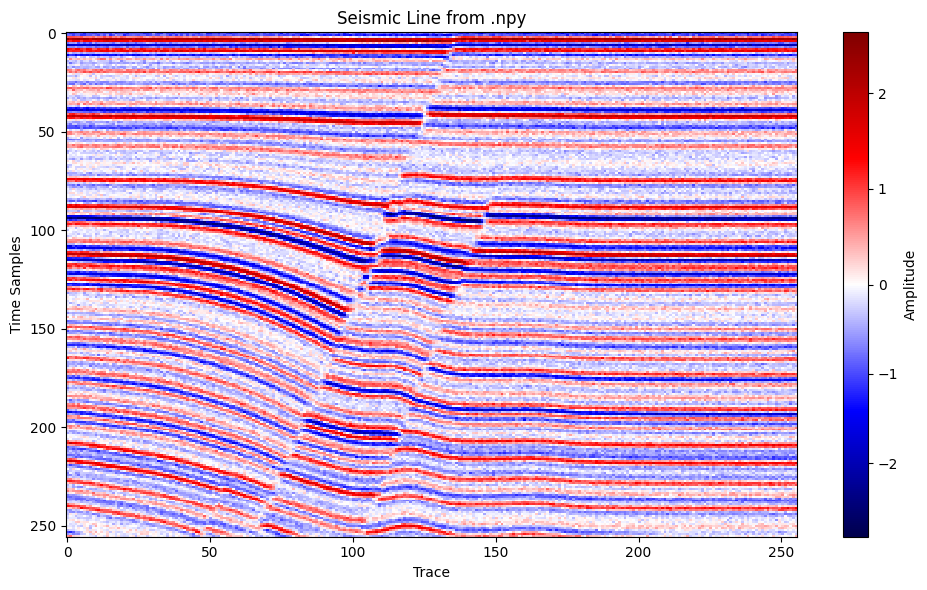

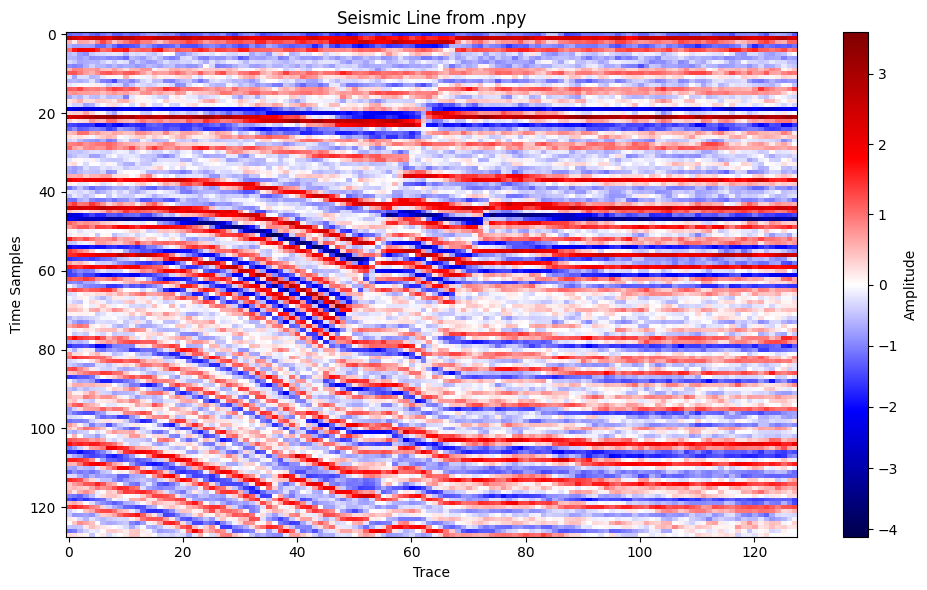

⚠️ No improvement for 2/24 epochs.
Epoch [32/150] - Train Loss: 0.002773 - Validation Loss: 0.002753 - Time: 4344.20s
⚠️ No improvement for 3/24 epochs.
Epoch [33/150] - Train Loss: 0.002758 - Validation Loss: 0.002825 - Time: 4344.64s
⚠️ No improvement for 4/24 epochs.
Epoch [34/150] - Train Loss: 0.002707 - Validation Loss: 0.002618 - Time: 4343.44s
✨ Validation loss improved — model saved!
Epoch [35/150] - Train Loss: 0.002723 - Validation Loss: 0.002743 - Time: 4342.84s
⚠️ No improvement for 1/24 epochs.
Epoch [36/150] - Train Loss: 0.002722 - Validation Loss: 0.002778 - Time: 4343.15s
⚠️ No improvement for 2/24 epochs.
Epoch [37/150] - Train Loss: 0.002651 - Validation Loss: 0.002850 - Time: 4343.50s
⚠️ No improvement for 3/24 epochs.
Epoch [38/150] - Train Loss: 0.002640 - Validation Loss: 0.002652 - Time: 4344.54s
⚠️ No improvement for 4/24 epochs.
Epoch [39/150] - Train Loss: 0.002614 - Validation Loss: 0.002705 - Time: 4344.72s
⚠️ No improvement for 5/24 epochs.
Epoch [40/150]

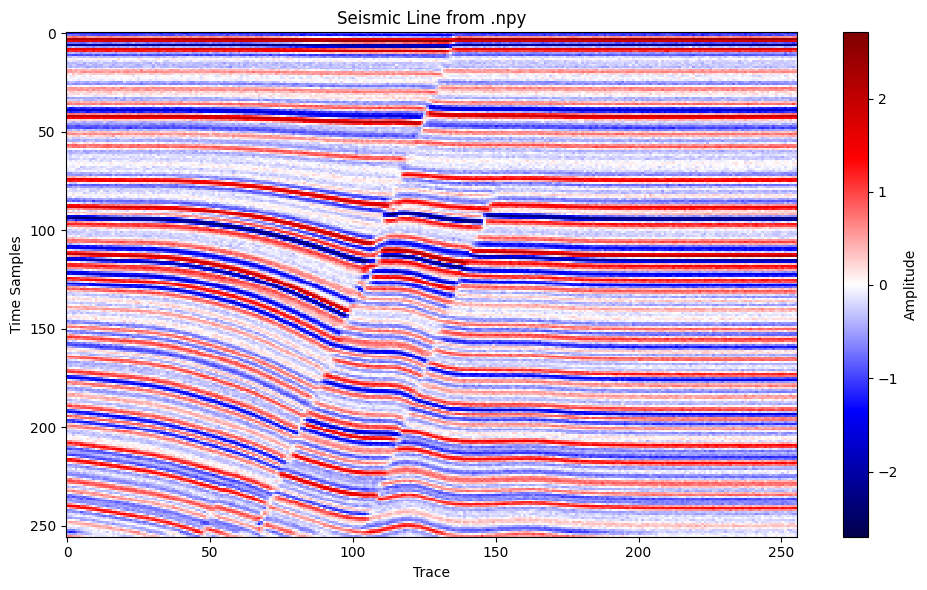

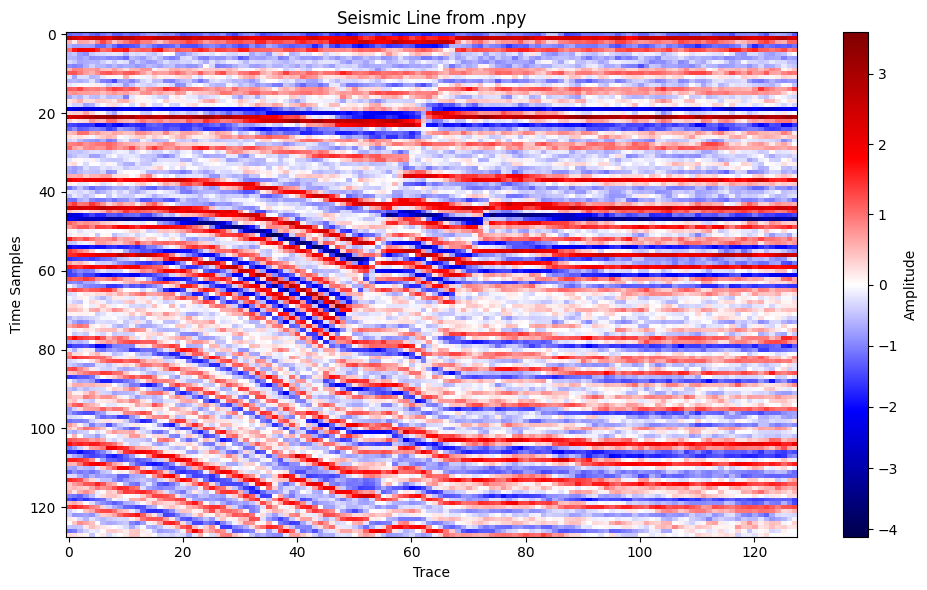

⚠️ No improvement for 7/24 epochs.
Epoch [42/150] - Train Loss: 0.002591 - Validation Loss: 0.002689 - Time: 4343.63s
⚠️ No improvement for 8/24 epochs.
Epoch [43/150] - Train Loss: 0.002575 - Validation Loss: 0.002662 - Time: 4340.89s
⚠️ No improvement for 9/24 epochs.
Epoch [44/150] - Train Loss: 0.002567 - Validation Loss: 0.002614 - Time: 4341.46s
✨ Validation loss improved — model saved!
Epoch [45/150] - Train Loss: 0.002529 - Validation Loss: 0.002586 - Time: 4342.99s
✨ Validation loss improved — model saved!
Epoch [46/150] - Train Loss: 0.002520 - Validation Loss: 0.002657 - Time: 4343.27s
⚠️ No improvement for 1/24 epochs.
Epoch [47/150] - Train Loss: 0.002526 - Validation Loss: 0.002417 - Time: 4343.95s
✨ Validation loss improved — model saved!
Epoch [48/150] - Train Loss: 0.002468 - Validation Loss: 0.002530 - Time: 4343.73s
⚠️ No improvement for 1/24 epochs.
Epoch [49/150] - Train Loss: 0.002454 - Validation Loss: 0.002748 - Time: 4346.11s
⚠️ No improvement for 2/24 epochs.


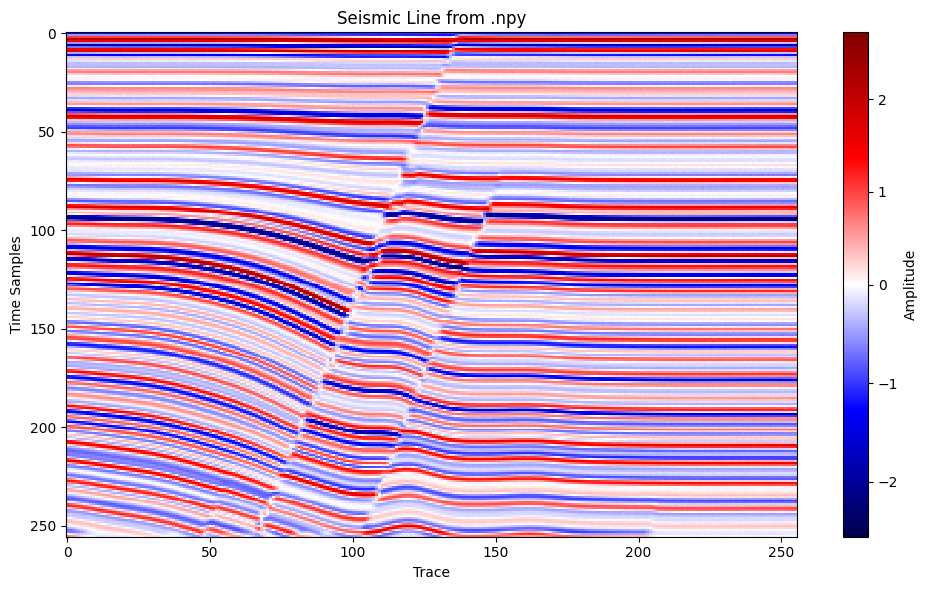

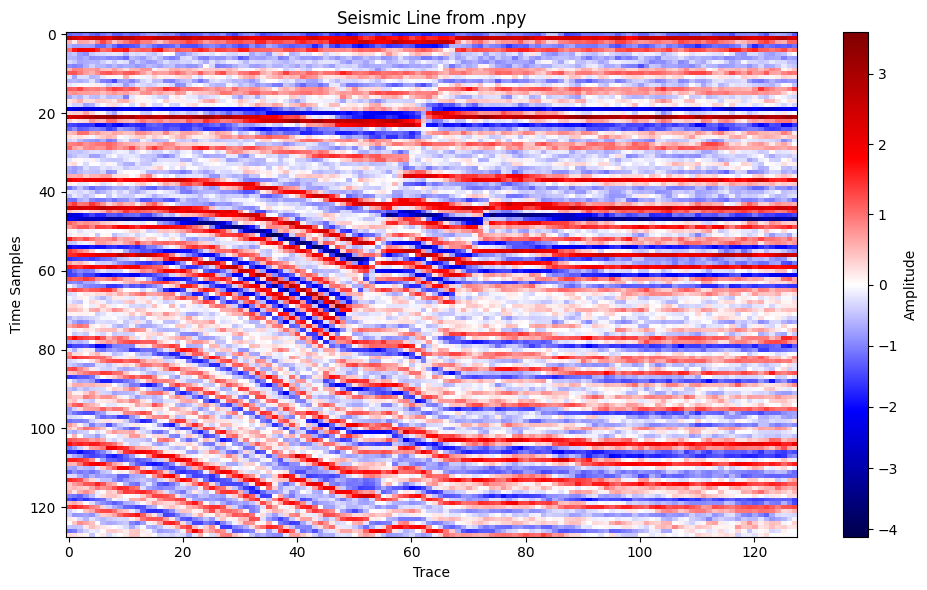

⚠️ No improvement for 4/24 epochs.
Epoch [52/150] - Train Loss: 0.002427 - Validation Loss: 0.002635 - Time: 4345.89s
⚠️ No improvement for 5/24 epochs.
Epoch [53/150] - Train Loss: 0.002425 - Validation Loss: 0.002502 - Time: 4346.64s
⚠️ No improvement for 6/24 epochs.
Epoch [54/150] - Train Loss: 0.002424 - Validation Loss: 0.002502 - Time: 4344.62s
⚠️ No improvement for 7/24 epochs.
Epoch [55/150] - Train Loss: 0.002369 - Validation Loss: 0.002581 - Time: 4344.26s
⚠️ No improvement for 8/24 epochs.
Epoch [56/150] - Train Loss: 0.002403 - Validation Loss: 0.002494 - Time: 4344.82s
⚠️ No improvement for 9/24 epochs.
Epoch [57/150] - Train Loss: 0.002341 - Validation Loss: 0.002439 - Time: 4345.56s
⚠️ No improvement for 10/24 epochs.
Epoch [58/150] - Train Loss: 0.002333 - Validation Loss: 0.002521 - Time: 4344.79s
⚠️ No improvement for 11/24 epochs.
Epoch [59/150] - Train Loss: 0.002336 - Validation Loss: 0.002480 - Time: 4344.09s
⚠️ No improvement for 12/24 epochs.
Epoch [60/150] - T

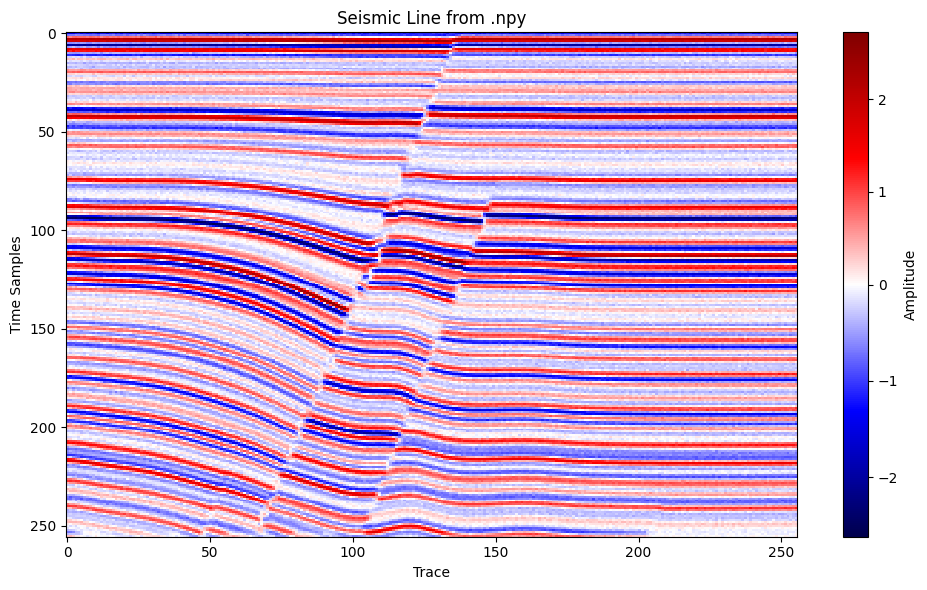

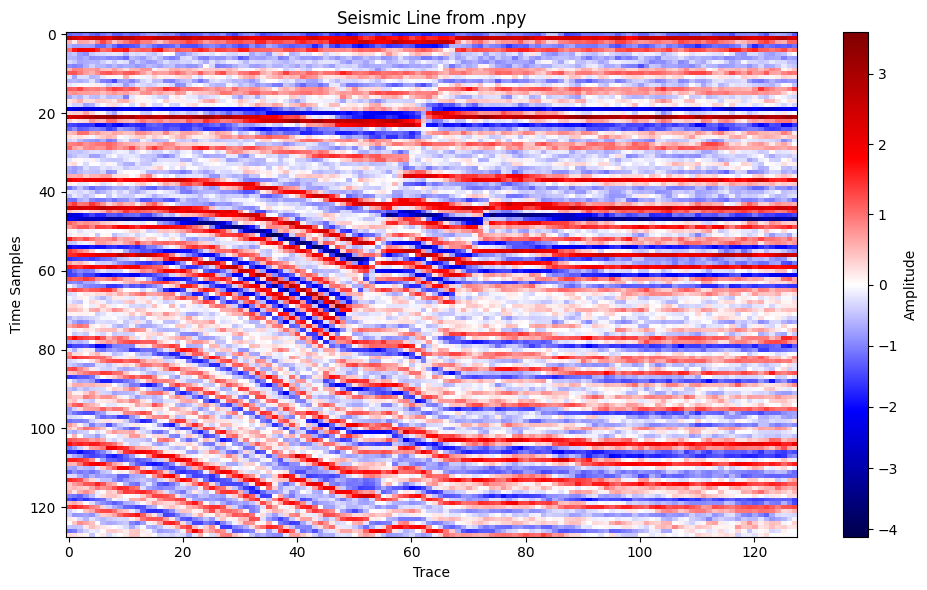

⚠️ No improvement for 14/24 epochs.
Epoch [62/150] - Train Loss: 0.002275 - Validation Loss: 0.002387 - Time: 4343.37s
✨ Validation loss improved — model saved!
Epoch [63/150] - Train Loss: 0.002254 - Validation Loss: 0.002508 - Time: 4344.57s
⚠️ No improvement for 1/24 epochs.
Epoch [64/150] - Train Loss: 0.002265 - Validation Loss: 0.002387 - Time: 4346.38s
✨ Validation loss improved — model saved!
Epoch [65/150] - Train Loss: 0.002223 - Validation Loss: 0.002530 - Time: 4348.80s
⚠️ No improvement for 1/24 epochs.
Epoch [66/150] - Train Loss: 0.002219 - Validation Loss: 0.002426 - Time: 4346.13s
⚠️ No improvement for 2/24 epochs.
Epoch [67/150] - Train Loss: 0.002214 - Validation Loss: 0.002514 - Time: 4346.75s
⚠️ No improvement for 3/24 epochs.
Epoch [68/150] - Train Loss: 0.002172 - Validation Loss: 0.002509 - Time: 4347.35s
⚠️ No improvement for 4/24 epochs.
Epoch [69/150] - Train Loss: 0.002165 - Validation Loss: 0.002399 - Time: 4345.73s
⚠️ No improvement for 5/24 epochs.
Epoch 

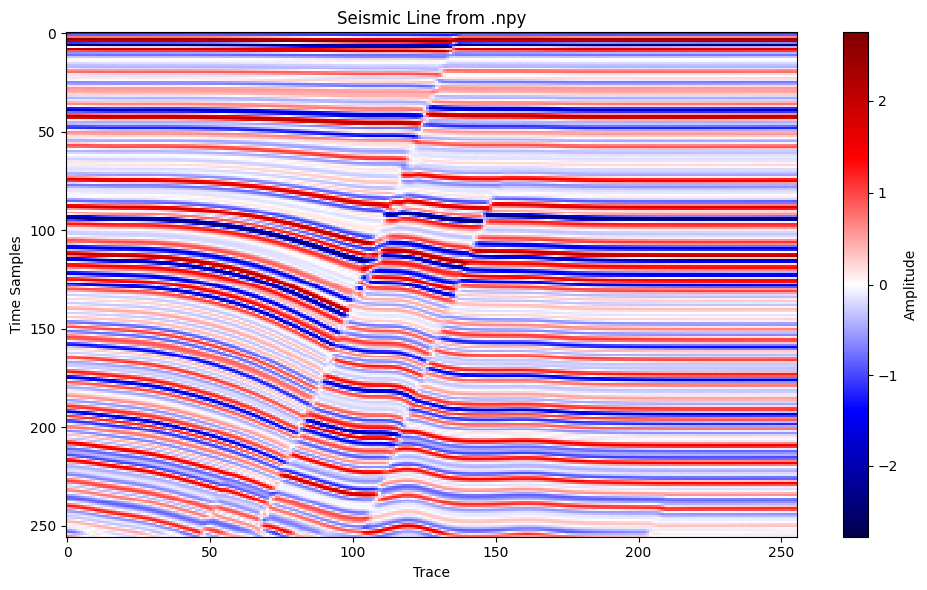

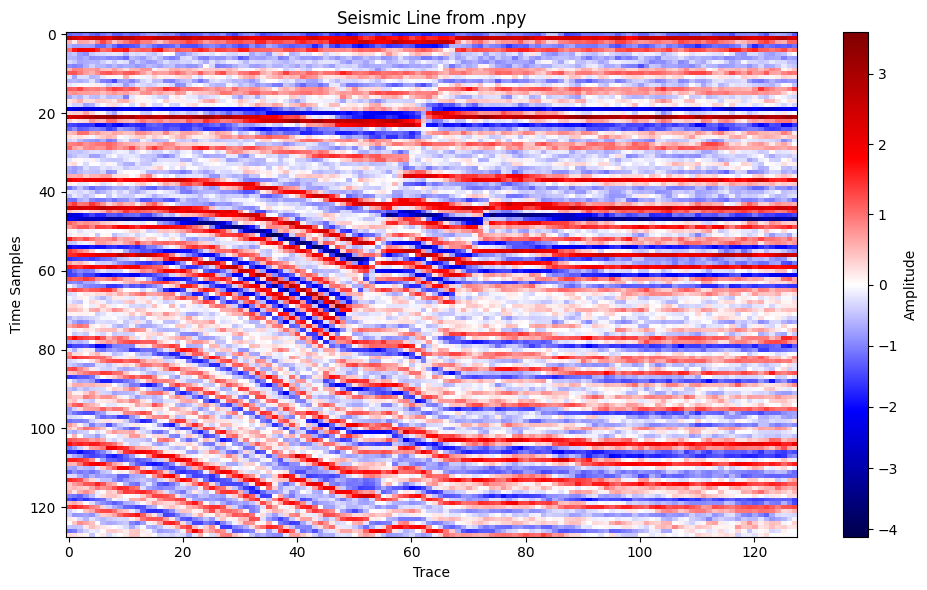

⚠️ No improvement for 7/24 epochs.
Epoch [72/150] - Train Loss: 0.002142 - Validation Loss: 0.002456 - Time: 4345.48s
⚠️ No improvement for 8/24 epochs.
Epoch [73/150] - Train Loss: 0.002100 - Validation Loss: 0.002398 - Time: 4346.94s
⚠️ No improvement for 9/24 epochs.
Epoch [74/150] - Train Loss: 0.002119 - Validation Loss: 0.002438 - Time: 4346.22s
⚠️ No improvement for 10/24 epochs.
Epoch [75/150] - Train Loss: 0.002105 - Validation Loss: 0.002500 - Time: 4347.17s
⚠️ No improvement for 11/24 epochs.
Epoch [76/150] - Train Loss: 0.002093 - Validation Loss: 0.002411 - Time: 4348.05s
⚠️ No improvement for 12/24 epochs.
Epoch [77/150] - Train Loss: 0.002063 - Validation Loss: 0.002365 - Time: 4347.75s
✨ Validation loss improved — model saved!
Epoch [78/150] - Train Loss: 0.002081 - Validation Loss: 0.002423 - Time: 4348.56s
⚠️ No improvement for 1/24 epochs.
Epoch [79/150] - Train Loss: 0.002034 - Validation Loss: 0.002335 - Time: 4352.97s
✨ Validation loss improved — model saved!
Epoc

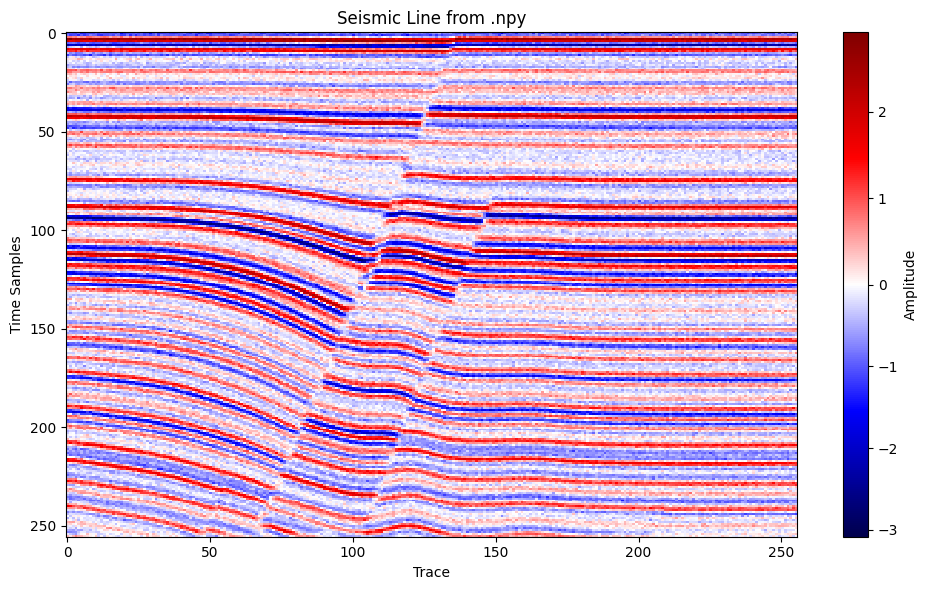

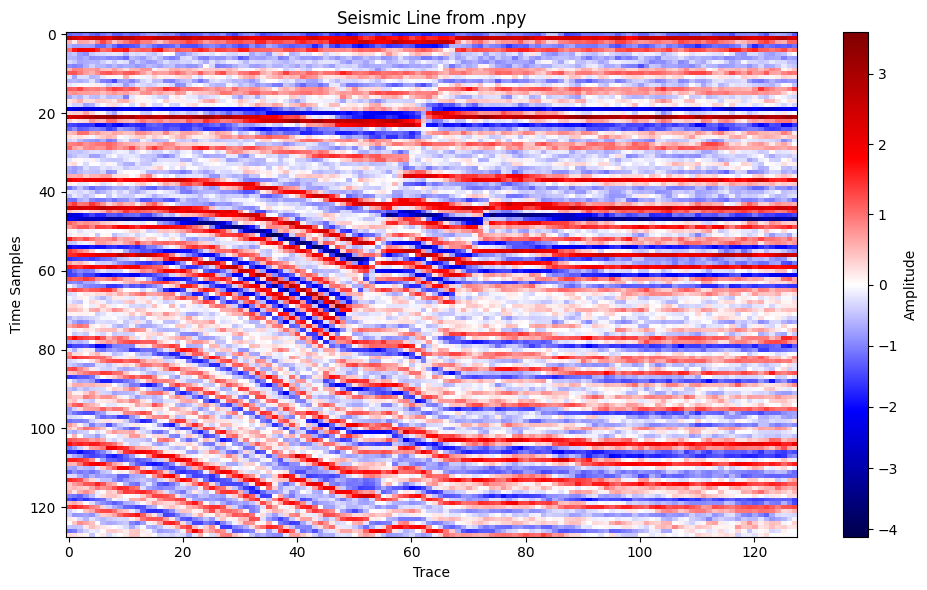

⚠️ No improvement for 2/24 epochs.
Epoch [82/150] - Train Loss: 0.001997 - Validation Loss: 0.002563 - Time: 4350.30s
⚠️ No improvement for 3/24 epochs.
Epoch [83/150] - Train Loss: 0.002000 - Validation Loss: 0.002483 - Time: 4350.91s
⚠️ No improvement for 4/24 epochs.
Epoch [84/150] - Train Loss: 0.001994 - Validation Loss: 0.002498 - Time: 4349.59s
⚠️ No improvement for 5/24 epochs.
Epoch [85/150] - Train Loss: 0.001991 - Validation Loss: 0.002475 - Time: 4350.32s
⚠️ No improvement for 6/24 epochs.
Epoch [86/150] - Train Loss: 0.001990 - Validation Loss: 0.002388 - Time: 4347.61s
⚠️ No improvement for 7/24 epochs.
Epoch [87/150] - Train Loss: 0.001962 - Validation Loss: 0.002351 - Time: 4346.77s
⚠️ No improvement for 8/24 epochs.
Epoch [88/150] - Train Loss: 0.001931 - Validation Loss: 0.002393 - Time: 4348.79s
⚠️ No improvement for 9/24 epochs.
Epoch [89/150] - Train Loss: 0.001916 - Validation Loss: 0.002402 - Time: 4347.87s
⚠️ No improvement for 10/24 epochs.
Epoch [90/150] - Tra

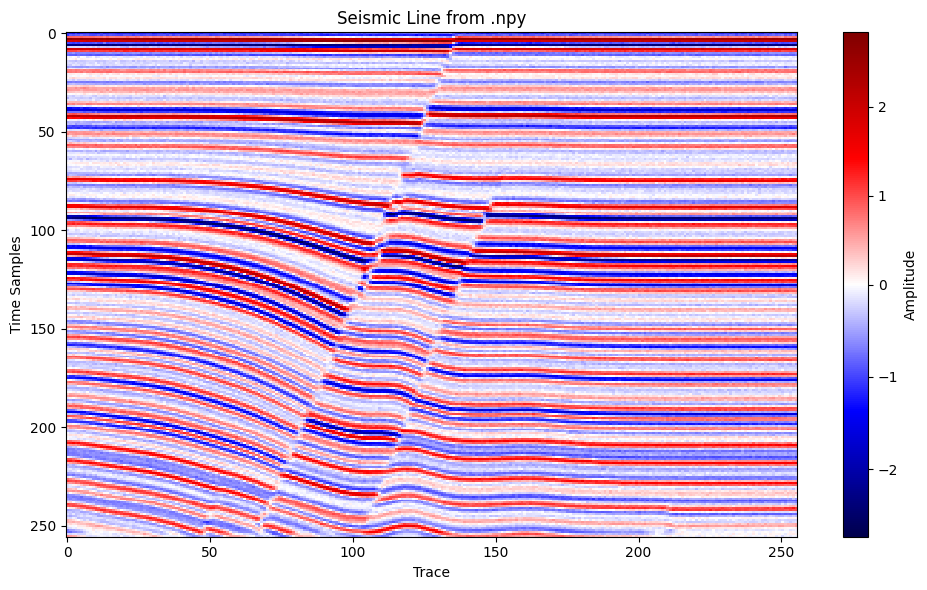

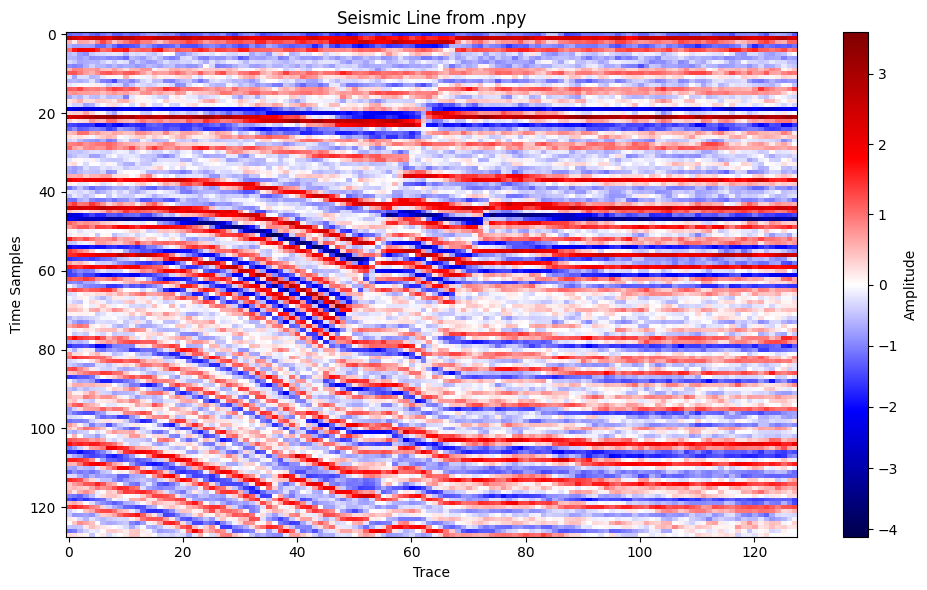

⚠️ No improvement for 12/24 epochs.
Epoch [92/150] - Train Loss: 0.001889 - Validation Loss: 0.002350 - Time: 4348.85s
⚠️ No improvement for 13/24 epochs.
Epoch [93/150] - Train Loss: 0.001891 - Validation Loss: 0.002539 - Time: 4348.38s
⚠️ No improvement for 14/24 epochs.
Epoch [94/150] - Train Loss: 0.001860 - Validation Loss: 0.002262 - Time: 4350.50s
✨ Validation loss improved — model saved!
Epoch [95/150] - Train Loss: 0.001836 - Validation Loss: 0.002251 - Time: 4349.30s
✨ Validation loss improved — model saved!
Epoch [96/150] - Train Loss: 0.001848 - Validation Loss: 0.002369 - Time: 4349.17s
⚠️ No improvement for 1/24 epochs.
Epoch [97/150] - Train Loss: 0.001826 - Validation Loss: 0.002212 - Time: 4348.64s
✨ Validation loss improved — model saved!
Epoch [98/150] - Train Loss: 0.001830 - Validation Loss: 0.002450 - Time: 4349.83s
⚠️ No improvement for 1/24 epochs.
Epoch [99/150] - Train Loss: 0.001778 - Validation Loss: 0.002429 - Time: 4349.73s
⚠️ No improvement for 2/24 epoch

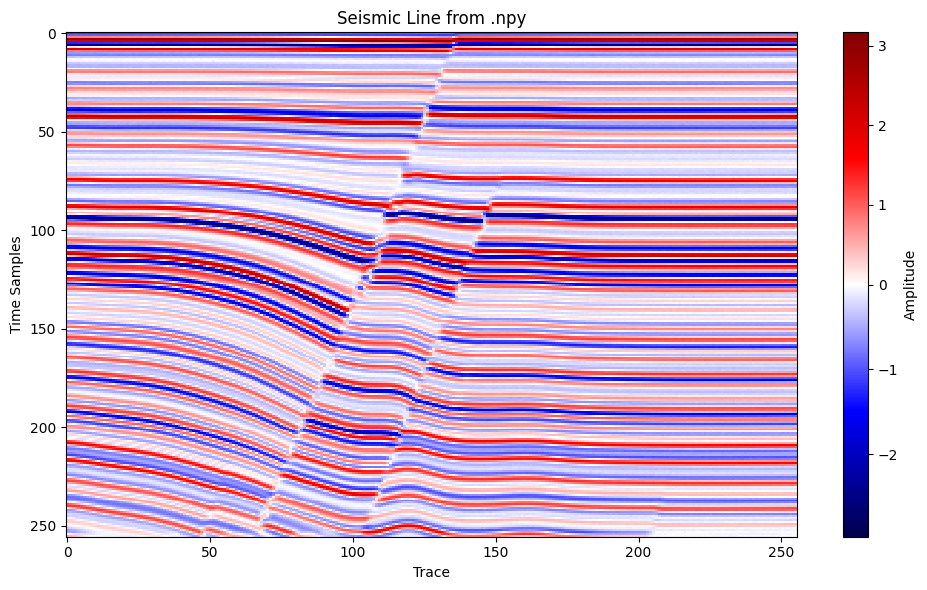

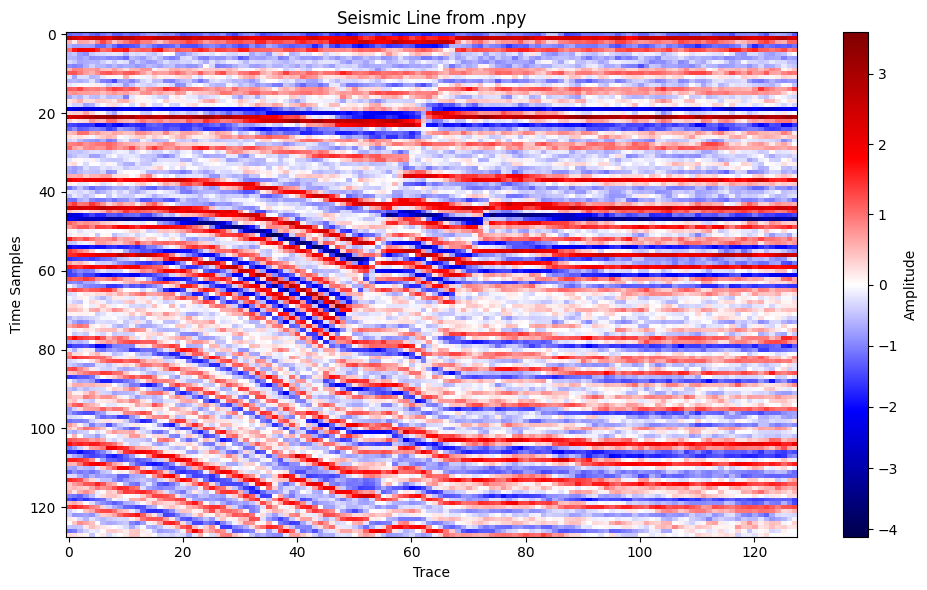

⚠️ No improvement for 4/24 epochs.
Epoch [102/150] - Train Loss: 0.001786 - Validation Loss: 0.002535 - Time: 4349.75s
⚠️ No improvement for 5/24 epochs.
Epoch [103/150] - Train Loss: 0.001765 - Validation Loss: 0.002331 - Time: 4351.14s
⚠️ No improvement for 6/24 epochs.
Epoch [104/150] - Train Loss: 0.001739 - Validation Loss: 0.002300 - Time: 4352.74s
⚠️ No improvement for 7/24 epochs.
Epoch [105/150] - Train Loss: 0.001734 - Validation Loss: 0.002395 - Time: 4353.06s
⚠️ No improvement for 8/24 epochs.
Epoch [106/150] - Train Loss: 0.001721 - Validation Loss: 0.002370 - Time: 4353.16s
⚠️ No improvement for 9/24 epochs.
Epoch [107/150] - Train Loss: 0.001706 - Validation Loss: 0.002424 - Time: 4351.53s
⚠️ No improvement for 10/24 epochs.
Epoch [108/150] - Train Loss: 0.001676 - Validation Loss: 0.002348 - Time: 4351.55s
⚠️ No improvement for 11/24 epochs.
Epoch [109/150] - Train Loss: 0.001695 - Validation Loss: 0.002382 - Time: 4351.58s
⚠️ No improvement for 12/24 epochs.
Epoch [110

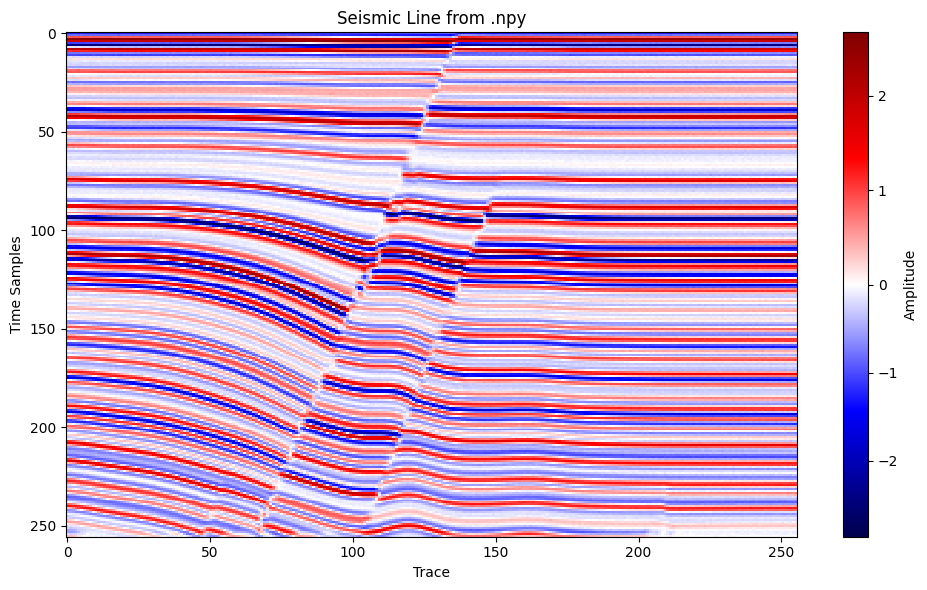

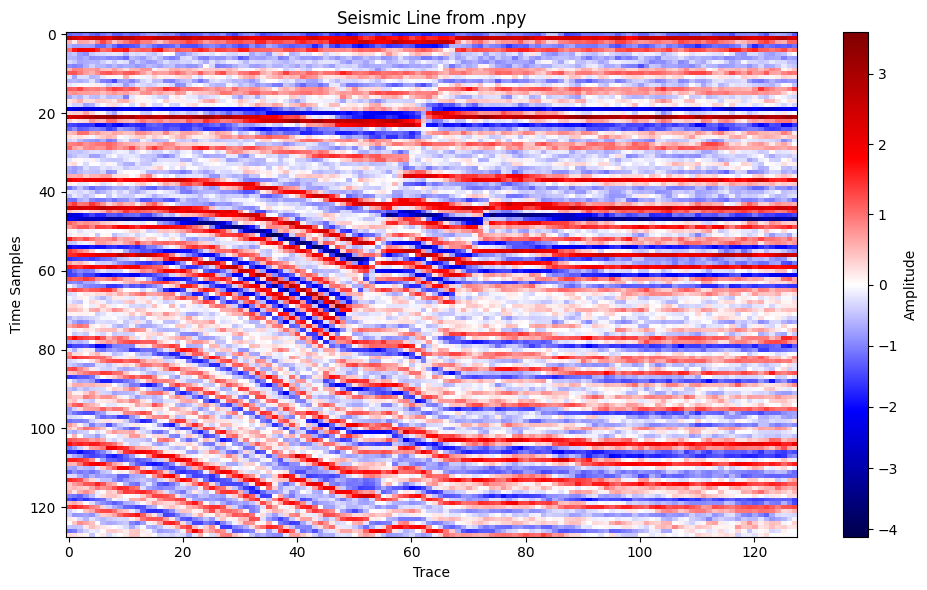

⚠️ No improvement for 14/24 epochs.
Epoch [112/150] - Train Loss: 0.001656 - Validation Loss: 0.002442 - Time: 4349.58s
⚠️ No improvement for 15/24 epochs.
Epoch [113/150] - Train Loss: 0.001654 - Validation Loss: 0.002322 - Time: 4348.83s
⚠️ No improvement for 16/24 epochs.
Epoch [114/150] - Train Loss: 0.001622 - Validation Loss: 0.002368 - Time: 4349.53s
⚠️ No improvement for 17/24 epochs.
Epoch [115/150] - Train Loss: 0.001612 - Validation Loss: 0.002325 - Time: 4348.99s
⚠️ No improvement for 18/24 epochs.
Epoch [116/150] - Train Loss: 0.001614 - Validation Loss: 0.002415 - Time: 4348.47s
⚠️ No improvement for 19/24 epochs.
Epoch [117/150] - Train Loss: 0.001600 - Validation Loss: 0.002374 - Time: 4349.94s
⚠️ No improvement for 20/24 epochs.
Epoch [118/150] - Train Loss: 0.001597 - Validation Loss: 0.002464 - Time: 4351.92s
⚠️ No improvement for 21/24 epochs.
Epoch [119/150] - Train Loss: 0.001593 - Validation Loss: 0.002437 - Time: 4352.54s
⚠️ No improvement for 22/24 epochs.
Epoc

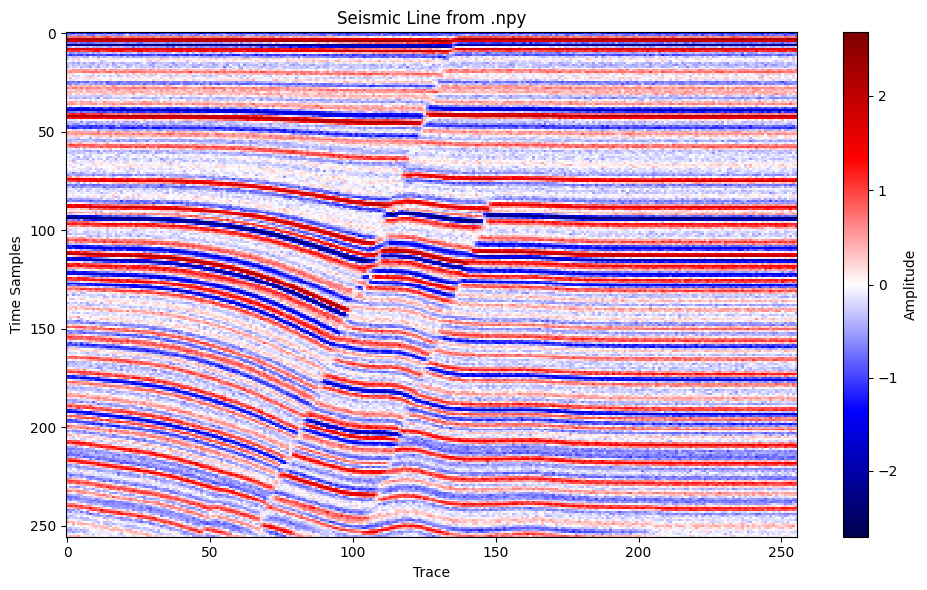

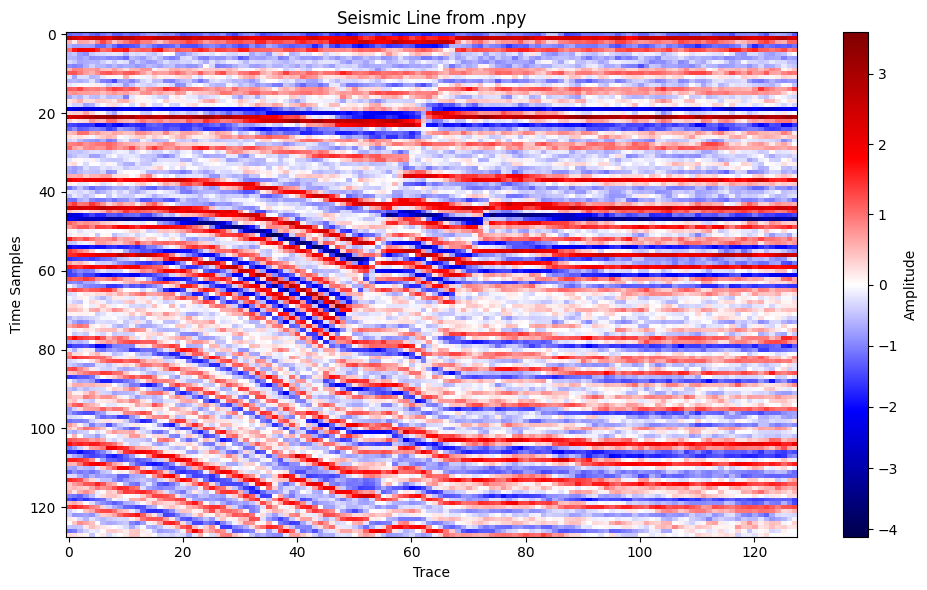

⚠️ No improvement for 24/24 epochs.
🛑 Early stopping triggered! Training stopped.


In [10]:
epochs = 150
patience = 24  # number of epochs to wait for improvement
best_val_loss = float('inf')
epochs_no_improve = 0

train_loss_per_epoch = []
val_loss_per_epoch = []

for epoch in range(epochs):
    start_time = time.time()
    epoch_loss = 0
    val_epoch_loss = 0

    # ===== Training =====
    model.train()
    for x, cond in train_loader:
        x, cond = x.to(device).unsqueeze(0).float(), cond.to(device).unsqueeze(0).float()
        t = torch.randint(1, num_timesteps, (x.shape[0],), device=device).long()

        loss = compute_loss(model, x, cond, t, Noise_schedule, device=device)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_train_loss = epoch_loss / len(train_loader)
    train_loss_per_epoch.append(avg_epoch_train_loss)

    # ===== Validation =====
    model.eval()
    with torch.no_grad():
        for x_val, cond_val in val_loader:
            x_val, cond_val = x_val.unsqueeze(0).to(device).float(), cond_val.unsqueeze(0).to(device).float()
            t_val = torch.randint(1, num_timesteps, (x_val.shape[0],), device=device).long()

            val_loss = compute_loss(model, x_val, cond_val, t_val, Noise_schedule, device=device)
            val_epoch_loss += val_loss.item()

        avg_epoch_val_loss = val_epoch_loss / len(val_loader)
        val_loss_per_epoch.append(avg_epoch_val_loss)

    end_time = time.time()
    epoch_duration = end_time - start_time
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_epoch_train_loss:.6f} - "
          f"Validation Loss: {avg_epoch_val_loss:.6f} - Time: {epoch_duration:.2f}s")

    # ===== Image Sampling (Optional) =====
    if epoch % 10 == 0 or epoch == epochs - 1:
        with torch.no_grad():
            cond_sample = next(iter(val_loader))[1].to(device).float().unsqueeze(0)
            sample_images = ddim_sample_conditional(
                model, image_size=(1,1, 256, 256),
                num_timesteps=num_timesteps,
                betas=cosine_schedule(num_timesteps),
                cond=cond_sample,  device=device
            )
            plot_2D_seismic(sample_images[0, :, :].cpu().numpy())
            plot_2D_seismic(cond_sample[0, :, :].cpu().numpy())

    # ===== Early Stopping =====
    if avg_epoch_val_loss < best_val_loss:
        best_val_loss = avg_epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), '/home/g202393750/Documents/Superresolution/The definitive model/models/best_model_SeisDiffattention_weights_standireze_ConelfavordeDios.pth')
        print("✨ Validation loss improved — model saved!")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve}/{patience} epochs.")

    if epochs_no_improve >= patience:
        print("🛑 Early stopping triggered! Training stopped.")
        break

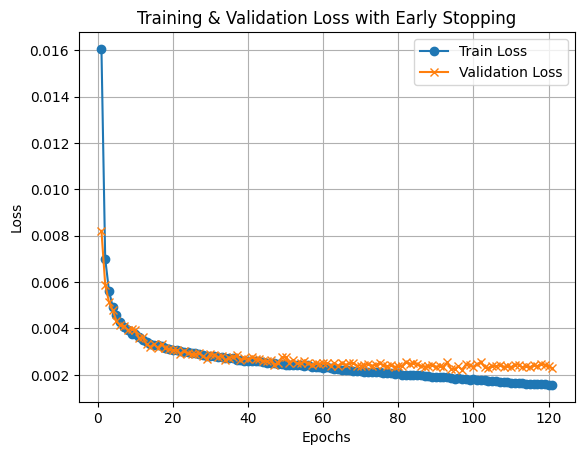

In [12]:
# ===== Final Plots =====
plt.plot(range(1, len(train_loss_per_epoch)+1), train_loss_per_epoch, marker='o', label='Train Loss')
plt.plot(range(1, len(val_loss_per_epoch)+1), val_loss_per_epoch, marker='x', label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss with Early Stopping")
plt.legend()
plt.grid()
plt.savefig('/home/g202393750/Documents/Superresolution/The definitive model/Figs/Loss/Loss_SeisDiffattention_standatize.png', dpi=300)
plt.show()

In [13]:
train_loss = np.array(train_loss_per_epoch)
np.save('/home/g202393750/Documents/Superresolution/The definitive model/Training/History/train_loss-SeisDiffattention_3.npy',train_loss)

In [14]:
val_loss = np.array(val_loss_per_epoch)
np.save('/home/g202393750/Documents/Superresolution/The definitive model/Training/History/val_loss-SeisDiffattention_3.npy',val_loss)

In [15]:
torch.save(model.state_dict(), '/home/g202393750/Documents/Superresolution/The definitive model/models/last_model_SeisDiffattention_weights_standirezeFNO_ConelfavordeDios.pth')

In [20]:
import itertools
from Diffusion_model.Reverse_process import *

# get the nth batch directly, e.g., n=5
n = 50
x_test, cond_test = next(itertools.islice(test_loader, n, None))
x_test, cond_test = x_test.to(device), cond_test.unsqueeze(0).to(device)
x_test = x_test.float()
cond_test = cond_test.float()
print(cond_test.shape)

sample_images = ddpm_sample_conditional_xtc(
            model,
            image_size=(1, cond.shape[2]*2, cond.shape[3]*2),
            num_timesteps=num_timesteps,
            betas = cosine_schedule(num_timesteps),
            cond=cond_test,
            batch_size=1,
            device=device
)
plot_2D_seismic(sample_images[0,:,:].cpu().numpy())
plot_2D_seismic(cond_test[0,:,:])
plot_2D_seismic(x_test[0,:,:])

torch.Size([1, 1, 128, 128])


RuntimeError: Expected all tensors to be on the same device, but got tensors is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_cat)